# Building objects from a signal you've never seen before

This is the whole interface. No training, no configuration beyond one
parameter. Same three calls that work on any signal with real rise/fall
structure.

In [1]:
from featuregraph_smoothing_core.behaviors.oscillation import OscillationConfig
from featuregraph_smoothing_core.datasets import wearable_hr  # confirm this matches the real exported name

hr = wearable_hr(subject="S01")  # confirm the real keyword arg / subject id
hr.head()

,seconds_from_start,timestamp_utc,heart_rate_bpm,subject
0,0.0,1.361383e+09,59.00,S01
1,1.0,1.361383e+09,79.50,S01
2,2.0,1.361383e+09,108.67,S01
3,3.0,1.361383e+09,101.25,S01
4,4.0,1.361383e+09,94.80,S01


## The raw signal

1 Hz heart rate. No prior knowledge of this dataset was used to get here.

(<Figure size 1600x300 with 1 Axes>,
 array([<Axes: xlabel='Time', ylabel='heart_rate_bpm'>], dtype=object))

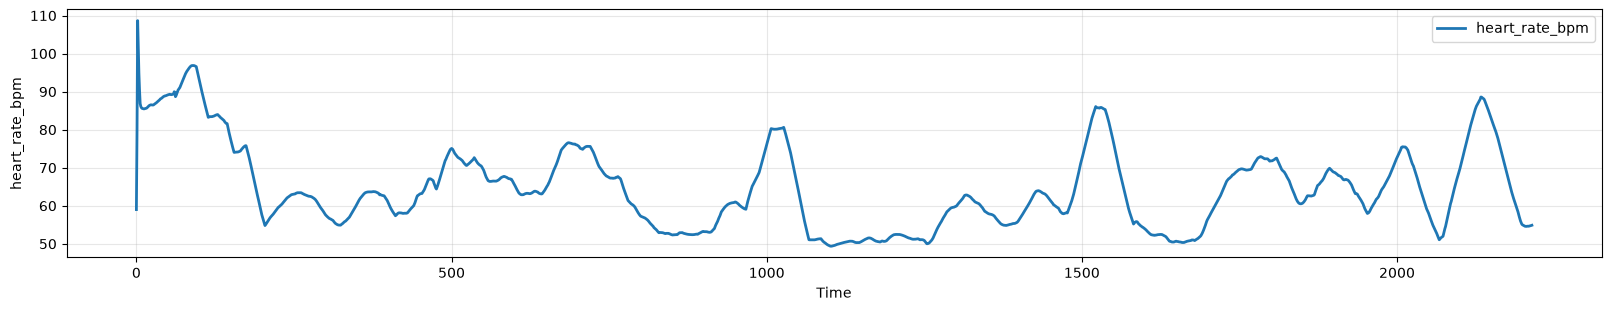

In [2]:
import featuregraph_smoothing_core as fg  # confirm this is how `fg.plot` is actually imported

fg.plot(hr, [["heart_rate_bpm"]])

## The whole interface: three lines

`smooth_window` is the one parameter. Everything else is automatic.

In [3]:
def build_objects(df, smooth_window):
    config = OscillationConfig(signal="heart_rate_bpm", smooth_window=smooth_window)
    added = config.add_primitives(df, "subject")
    summary = config.summarize(added, ["subject", config.trough_event_id_col]).reset_index()
    return added, summary

added_20, summary_20 = build_objects(hr, smooth_window=20)
print(f"smooth_window=20  ->  {len(summary_20)} objects")

smooth_window=20  ->  22 objects


(<Figure size 1600x660 with 3 Axes>,
 array([<Axes: ylabel='heart_rate_bpm'>,
        <Axes: ylabel='heart_rate_bpm_smooth'>,
        <Axes: xlabel='Time', ylabel='exit_heart_rate_bpm_rising'>],
       dtype=object))

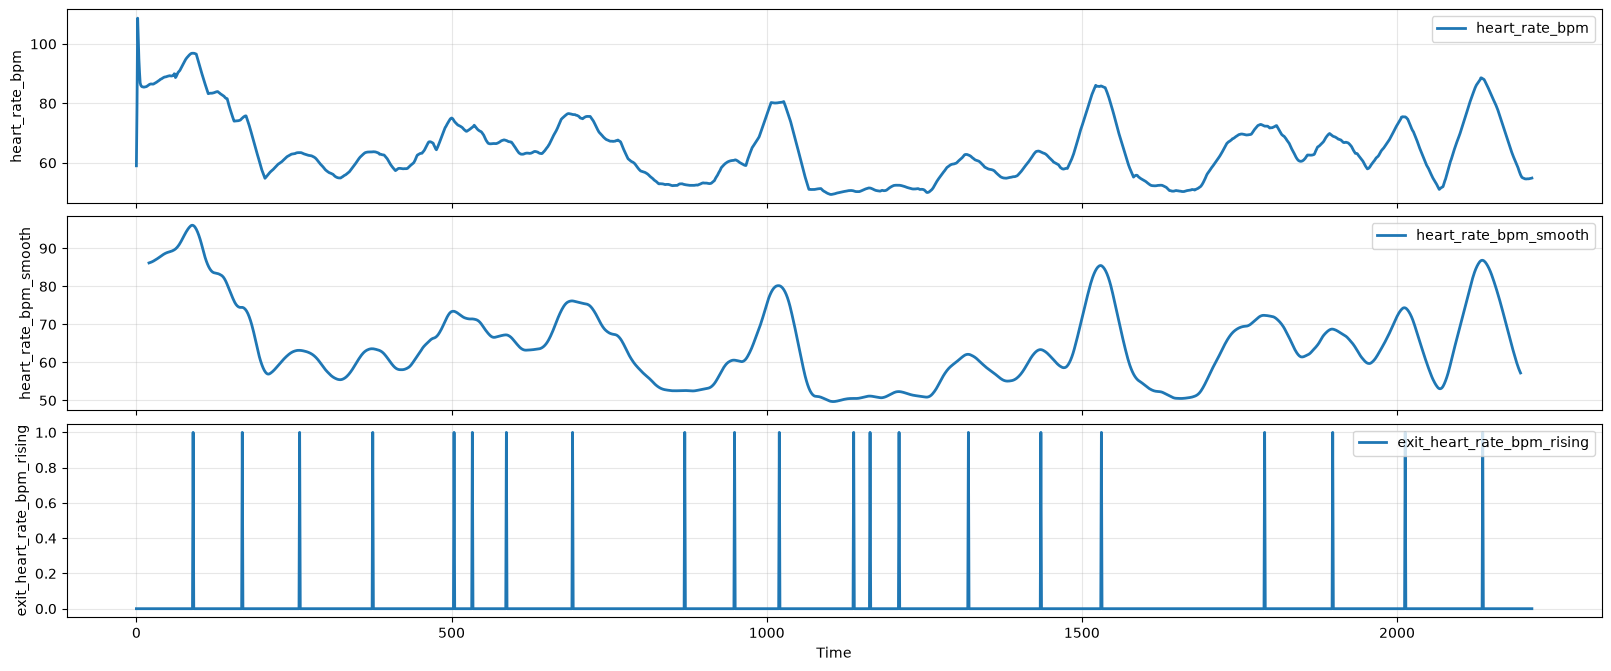

In [4]:
fg.plot(added_20, [
    ["heart_rate_bpm"],
    ["heart_rate_bpm_smooth"],
    ["exit_heart_rate_bpm_rising"],
])

## The same signal, one number changed

Nothing else about the call changes.

In [5]:
added_100, summary_100 = build_objects(hr, smooth_window=100)
print(f"smooth_window=100  ->  {len(summary_100)} objects")

smooth_window=100  ->  9 objects


(<Figure size 1600x660 with 3 Axes>,
 array([<Axes: ylabel='heart_rate_bpm'>,
        <Axes: ylabel='heart_rate_bpm_smooth'>,
        <Axes: xlabel='Time', ylabel='exit_heart_rate_bpm_rising'>],
       dtype=object))

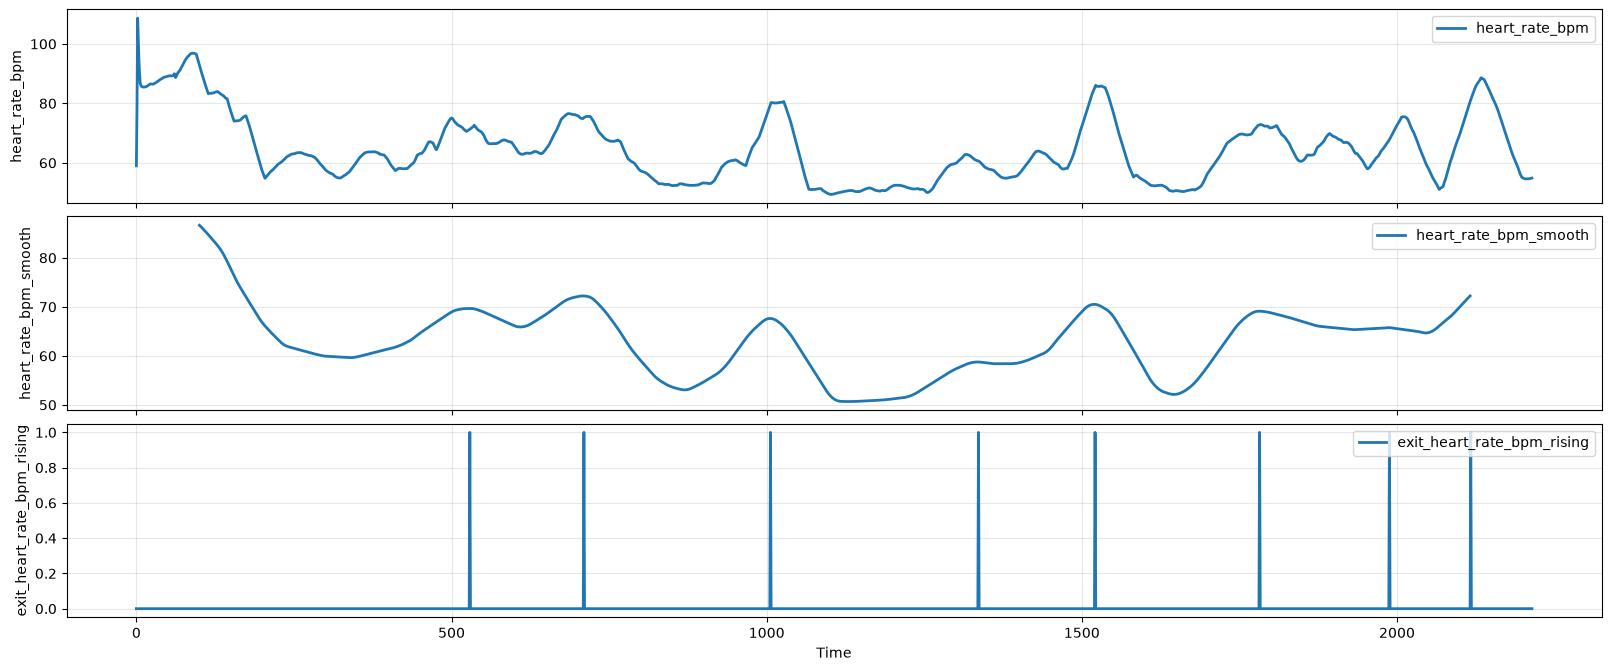

In [6]:
fg.plot(added_100, [
    ["heart_rate_bpm"],
    ["heart_rate_bpm_smooth"],
    ["exit_heart_rate_bpm_rising"],
])

## Side by side

Same signal. Same three lines of code. One parameter changed.

In [7]:
import pandas as pd

pd.DataFrame({
    "smooth_window": [20, 100],
    "objects_detected": [len(summary_20), len(summary_100)],
})

,smooth_window,objects_detected
0,20,22
1,100,9


Both are real, valid runs of the exact same compiler. Neither was chosen
because it's known to be correct for this signal -- they're just two
numbers that seemed reasonable to try.

**Which one is right?**

There's no way to tell from here. That's not a gap in this notebook --
it's the actual open question for any new signal, and it's exactly what
validated, signal-derived parameter selection answers.